In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
from constants import EQ, HH, custom_tech_colors, custom_metal_colors

In [3]:
# Damage files
df_sps_damage = pd.read_csv(r'results/df_sps_damage_regionalized.csv')
df_nze_damage = pd.read_csv(r'results/df_nze_damage_regionalized.csv')
df_ssp2_damage = pd.read_csv(r'results/df_ssp2_damage_regionalized.csv')

In [4]:
df_etm_roe = pd.read_csv(r'results/energy_transition_vs_roe.csv')

In [5]:
df_sps_damage['Metal'].unique()

array(['Aluminium', 'Arsenic', 'Boron', 'Cadmium', 'Chromium', 'Cobalt',
       'Copper', 'Dysprosium', 'Gallium', 'Graphite (battery-grade)',
       'Hafnium', 'Indium', 'Iridium', 'Lanthanum', 'Lead', 'Lithium',
       'Magnesium', 'Manganese', 'Molybdenum', 'Neodymium', 'Nickel',
       'Niobium', 'PGMs', 'Praseodymium', 'Selenium', 'Silicon', 'Silver',
       'Tantalum', 'Tellurium', 'Terbium', 'Tin', 'Titanium', 'Tungsten',
       'Vanadium', 'Yttrium', 'Zinc', 'Zirconium'], dtype=object)

In [6]:
df_sps_damage['Technology'].unique()

array(['Electricity networks', 'Solar PV', 'Wind',
       'Other low emissions power generation',
       'Low emissions power generation', 'Electric vehicles',
       'Grid battery storage', 'Hydrogen technologies'], dtype=object)

In [7]:
# Group into one category for plotting
df_sps_damage["Technology"] = df_sps_damage["Technology"].replace("Other low emissions power generation", "Low emissions power generation")
df_nze_damage["Technology"] = df_nze_damage["Technology"].replace("Other low emissions power generation", "Low emissions power generation")

In [9]:
# Rename
df_sps_damage["Metal"] = df_sps_damage["Metal"].replace("Graphite (battery-grade)", "Graphite")
df_nze_damage["Metal"] = df_nze_damage["Metal"].replace("Graphite (battery-grade)", "Graphite")

In [10]:
# Midpoints file
df_sps_mp = pd.read_csv(r'results/df_sps_midpoints_regionalized.csv')
df_nze_mp = pd.read_csv(r'results/df_nze_midpoints_regionalized.csv')

In [11]:
# Additional impact file
df_comparison = pd.read_csv(r'results/comparaison_benefits_burden.csv')

In [12]:
### SET GLOBAL MATPLOTLIB PARAMS
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42  # to Ensure TrueType fonts are embedded
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'arial'
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 10
rcParams['legend.fontsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['axes.titlesize'] = 12
import seaborn as sns
sns.reset_orig()

# Stacked bar from 2022 to 2050 for metals and technologies

In [13]:
from plotting_functions import plot_stacked_area

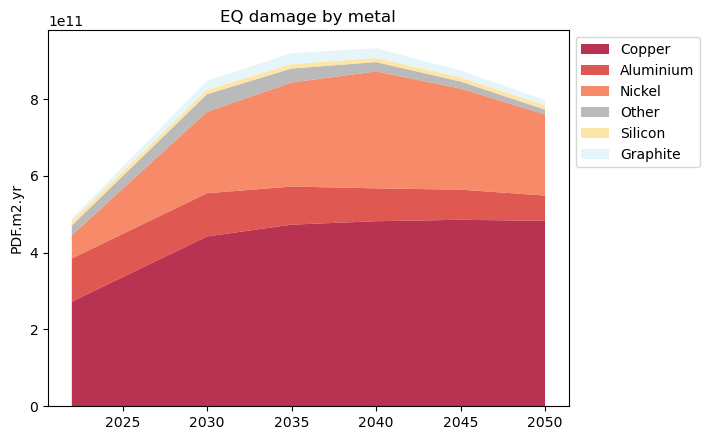

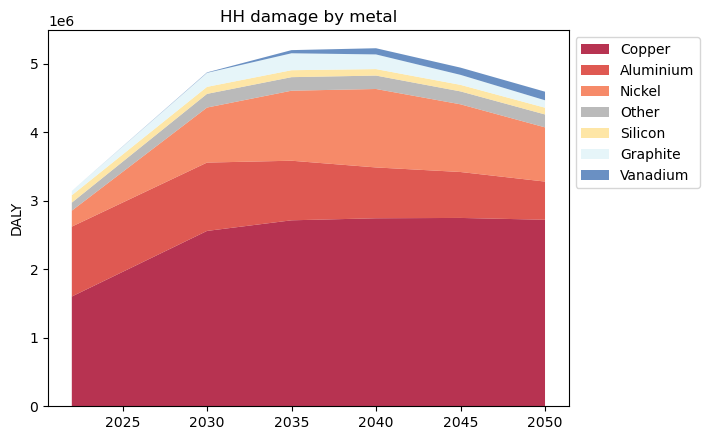

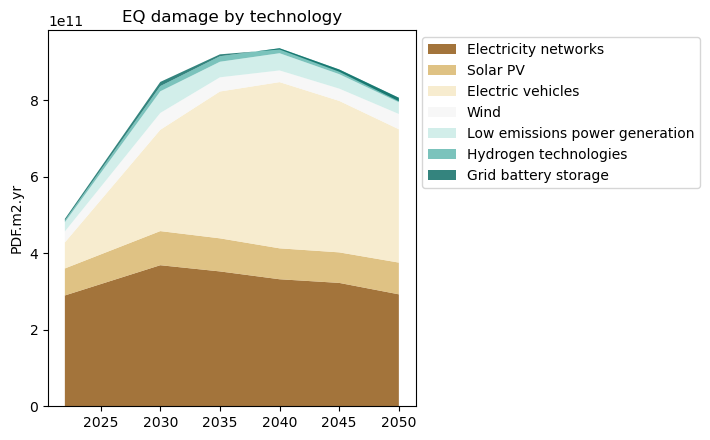

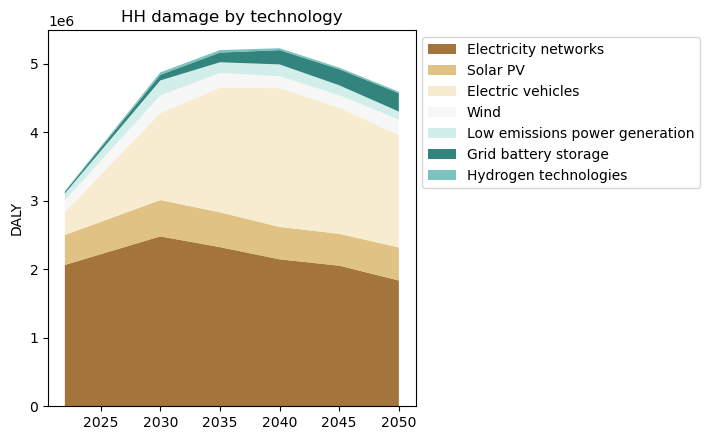

In [14]:
# Generate plots
fig_sps_metal_eq = plot_stacked_area(df_sps_damage, "Metal", "Total ecosystem quality", "EQ damage by metal", "PDF.m2.yr", custom_colors=custom_metal_colors, save_path="results/plots/stacked_area_metals_technologies/fig_sps_metal_eq")
fig_sps_metal_hh = plot_stacked_area(df_sps_damage, "Metal", "Total human health", "HH damage by metal", "DALY", custom_colors=custom_metal_colors, save_path="results/plots/stacked_area_metals_technologies/fig_sps_metal_hh")
fig_sps_tech_eq = plot_stacked_area(df_sps_damage, "Technology", "Total ecosystem quality", "EQ damage by technology", "PDF.m2.yr", custom_colors=custom_tech_colors, save_path="results/plots/stacked_area_metals_technologies/fig_sps_tech_eq")
fig_sps_tech_hh = plot_stacked_area(df_sps_damage, "Technology", "Total human health", "HH damage by technology", "DALY", custom_colors=custom_tech_colors, save_path="results/plots/stacked_area_metals_technologies/fig_sps_tech_hh")

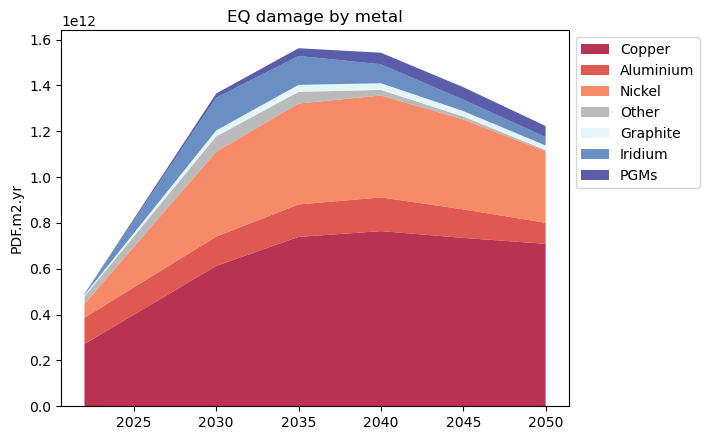

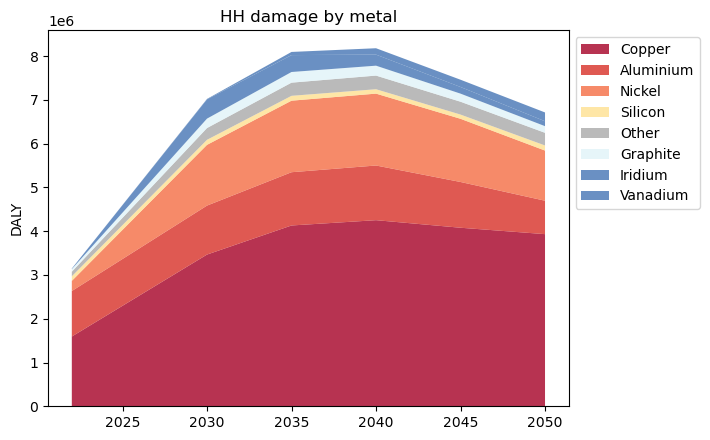

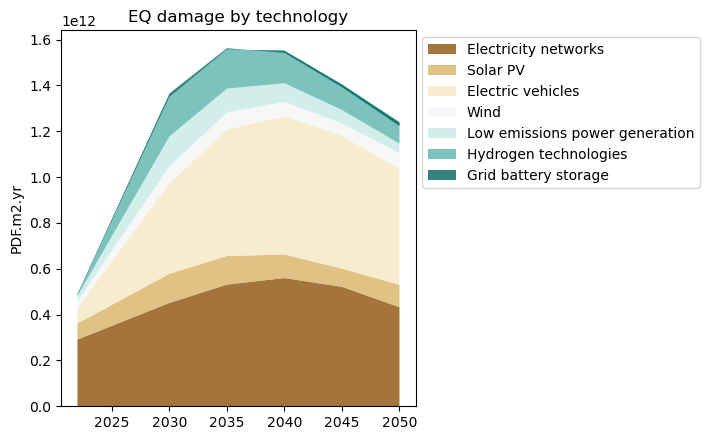

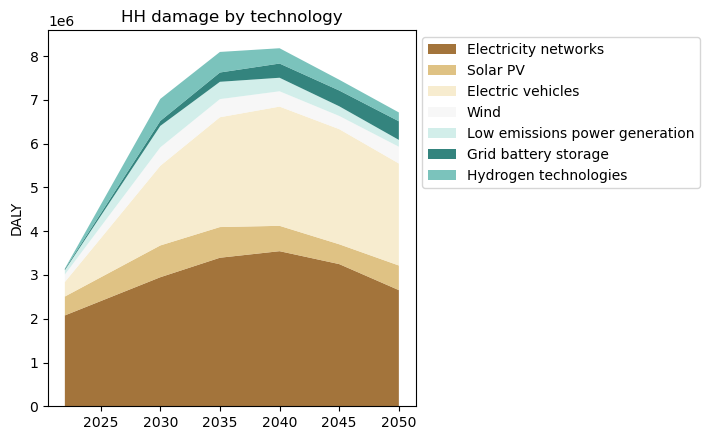

In [15]:
fig_nze_metal_eq = plot_stacked_area(df_nze_damage, "Metal", "Total ecosystem quality", "EQ damage by metal", "PDF.m2.yr", custom_colors=custom_metal_colors, save_path="results/plots/stacked_area_metals_technologies/fig_nze_metal_eq")
fig_nze_metal_hh = plot_stacked_area(df_nze_damage, "Metal", "Total human health", "HH damage by metal", "DALY", custom_colors=custom_metal_colors, save_path="results/plots/stacked_area_metals_technologies/fig_nze_metal_hh")
fig_nze_metal_eq = plot_stacked_area(df_nze_damage, "Technology", "Total ecosystem quality", "EQ damage by technology", "PDF.m2.yr", custom_colors=custom_tech_colors, save_path="results/plots/stacked_area_metals_technologies/fig_nze_tech_eq")
fig_nze_tech_hh = plot_stacked_area(df_nze_damage, "Technology", "Total human health", "HH damage by technology", "DALY", custom_colors=custom_tech_colors, save_path="results/plots/stacked_area_metals_technologies/fig_nze_tech_hh")

In [16]:
from plotting_functions import plot_combined_stacked_area

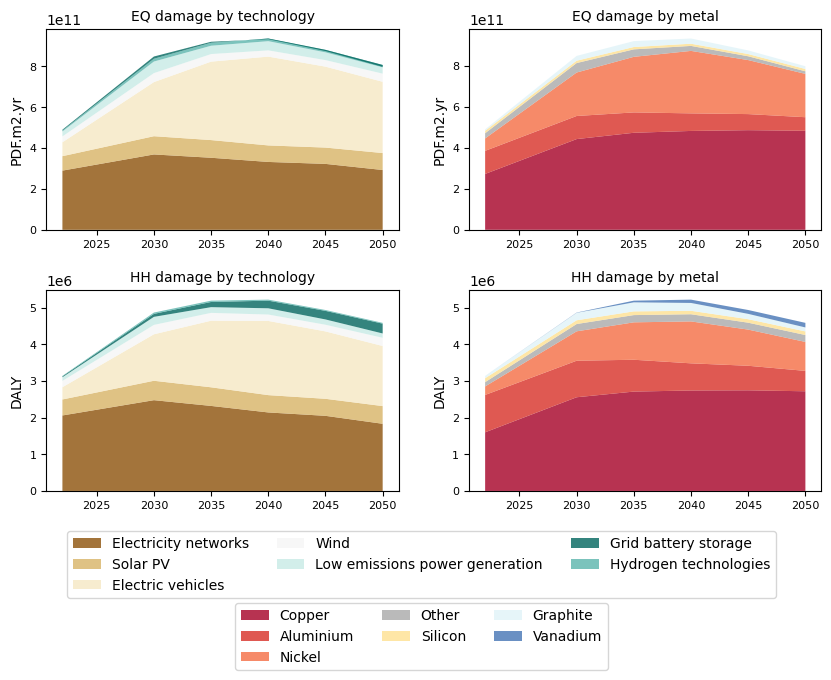

In [17]:
stacked_area_sps = plot_combined_stacked_area(
    df=df_sps_damage,
    value_cols=["Total ecosystem quality", "Total human health"],
    group_by_options=["Technology", "Metal"],
    titles=[
        ["EQ damage by technology", "EQ damage by metal"],
        ["HH damage by technology", "HH damage by metal"]
    ],
    y_labels=["PDF.m2.yr", "DALY"],
    custom_colors_dict={
        "Technology": custom_tech_colors,
        "Metal": custom_metal_colors
    },
    save_path="results/plots/stacked_area_metals_technologies/combined_stacked_area_sps"
)


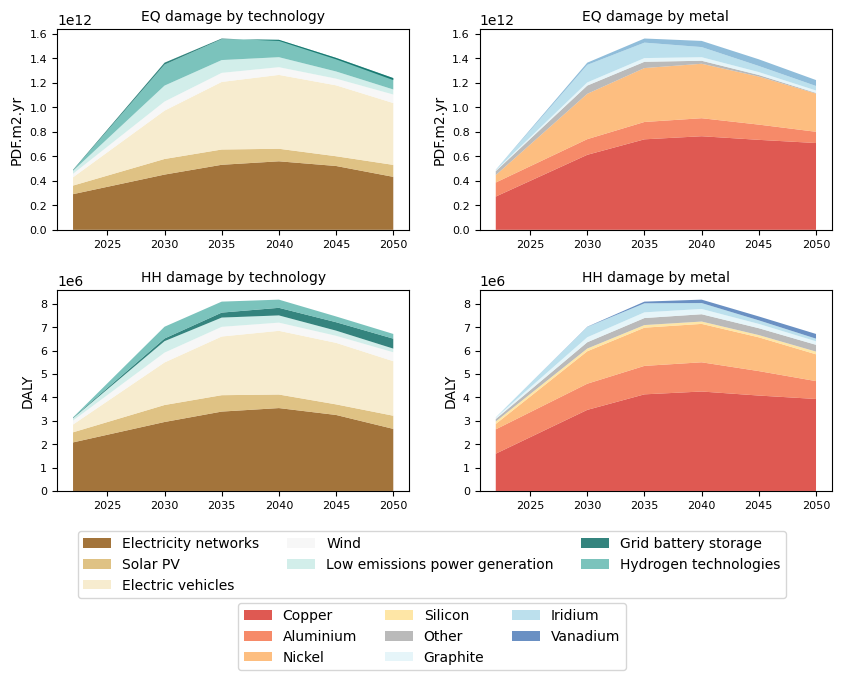

In [50]:
stacked_area_nze = plot_combined_stacked_area(
    df=df_nze_damage,
    value_cols=["Total ecosystem quality", "Total human health"],
    group_by_options=["Technology", "Metal"],
    titles=[
        ["EQ damage by technology", "EQ damage by metal"],
        ["HH damage by technology", "HH damage by metal"]
    ],
    y_labels=["PDF.m2.yr", "DALY"],
    custom_colors_dict={
        "Technology": custom_tech_colors,
        "Metal": custom_metal_colors
    },
    save_path="results/plots/stacked_area_metals_technologies/combined_stacked_area_nze"
)



# Contribution analysis

## Stacked barplot for MP contribution per year

In [ ]:
from plotting_functions import plot_stacked_bar

In [ ]:
# Define the directory for saving bar plots
barplot_dir = "results/plots/stacked_barplots_mp_contribution"
os.makedirs(barplot_dir, exist_ok=True)

In [ ]:
fig_sps_mp_eq = plot_stacked_bar(df_sps_damage, EQ, "Total ecosystem quality",
                 "Midpoint Contributions to Ecosystem Quality",
                 custom_colors=None,
                 save_path=f"{barplot_dir}/fig_sps_mp_eq")

In [ ]:
fig_sps_mp_hh = plot_stacked_bar(df_sps_damage, HH, "Total human health", 
                                 "Midpoint Contributions to Human Health", 
                                 custom_colors=None,
                                 save_path=f"{barplot_dir}/fig_sps_mp_hh")

In [ ]:
fig_nze_mp_eq = plot_stacked_bar(df_nze_damage, EQ, "Total ecosystem quality",
                 "Midpoint Contributions to Ecosystem Quality", 
                 custom_colors=None,
                 save_path=f"{barplot_dir}/fig_nze_mp_eq")

In [ ]:
fig_nze_mp_hh = plot_stacked_bar(df_nze_damage, HH, "Total human health", 
                                 "Midpoint Contributions to Human Health",
                                 custom_colors=None,
                                 save_path=f"{barplot_dir}/fig_nze_mp_hh")

## Barplot for MP contribution over the period

In [ ]:
from plotting_functions import plot_cumulative_midpoint_contribution

In [ ]:
fig_sps_mp_eq_cum = plot_cumulative_midpoint_contribution(df_sps_damage, EQ, "Total ecosystem quality",
                                      "Cumulative Midpoint Contributions (2022-2050) - Ecosystem Quality",
                                      save_path="results/plots/barplots_mp_contribution_cumulative/fig_sps_mp_eq_cum")

fig_sps_mp_hh_cum = plot_cumulative_midpoint_contribution(df_sps_damage, HH, "Total human health",
                                      "Cumulative Midpoint Contributions (2022-2050) - Human Health",
                                      save_path="results/plots/barplots_mp_contribution_cumulative/fig_sps_mp_hh_cum")


In [ ]:
fig_nze_mp_eq_cum = plot_cumulative_midpoint_contribution(df_nze_damage, EQ, "Total ecosystem quality",
                                      "Cumulative Midpoint Contributions (2022-2050) - Ecosystem Quality",
                                      save_path="results/plots/barplots_mp_contribution_cumulative/fig_nze_mp_eq_cum")

fig_nze_mp_hh_cum = plot_cumulative_midpoint_contribution(df_nze_damage, HH, "Total human health",
                                      "Cumulative Midpoint Contributions (2022-2050) - Human Health",
                                      save_path="results/plots/barplots_mp_contribution_cumulative/fig_nze_mp_hh_cum")

# Sankey

In [ ]:
from plotting_functions import create_sankey

In [ ]:
from constants import agg_mapping_eq, agg_mapping_hh, metal_map

In [ ]:
# Define directory for saving Sankey diagrams
sankey_dir = "results/plots/sankey"
os.makedirs(sankey_dir, exist_ok=True)

In [ ]:
fig_sps_eq = create_sankey(
    df_sps_damage,
    total_col="Total ecosystem quality",
    impact_columns=EQ,
    #title="",
    save_path=f"{sankey_dir}/sps_eq",
    agg_mapping=agg_mapping_eq,
    metal_mapping=metal_map
)

fig_sps_hh = create_sankey(
    df_sps_damage,
    total_col="Total human health",
    impact_columns=HH,
    #title="",
    save_path=f"{sankey_dir}/sps_hh",
    agg_mapping=agg_mapping_hh,
    metal_mapping=metal_map
)


In [ ]:
fig_nze_eq = create_sankey(
    df_nze_damage,
    total_col="Total ecosystem quality",
    impact_columns=EQ,
    #title="",
    save_path=f"{sankey_dir}/nze_eq",
    agg_mapping=agg_mapping_eq,
    metal_mapping=metal_map
)

fig_nze_hh = create_sankey(
    df_nze_damage,
    total_col="Total human health",
    impact_columns=HH,
    #title="",
    save_path=f"{sankey_dir}/nze_hh",
    agg_mapping=agg_mapping_hh,
    metal_mapping=metal_map
)

# Benefits vs burden of the transition

In [ ]:
from plotting_functions import plot_lineplot_burden_comparison, plot_lineplot_burden_comparison_combined

In [ ]:
plot_lineplot_burden_comparison(df_comparison, save_path='results/plots/burden_comparison/lineplot')

In [ ]:
# Plotting the combined figure
plot_lineplot_burden_comparison_combined(df_comparison, save_path='results/plots/burden_comparison/lineplot_combined')

In [ ]:
from plotting_functions import plot_lineplot_logscale, plot_percentage_transition

In [25]:
import pandas as pd
import numpy as np
import os
import math
# Matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import rcParams
from matplotlib.lines import Line2D
import seaborn as sns
import plotly.graph_objects as go

In [45]:
plot_lineplot_logscale(df_comparison, save_path='results/plots/burden_comparison/lineplot_logscale')

In [ ]:
plot_percentage_transition(df_comparison, save_path='results/plots/burden_comparison/percentage')

# Energy transition vs rest of the economy

## Subplots

### Quantities

In [66]:
from plotting_functions import plot_all_metals_subplots

In [67]:
plot_all_metals_subplots(
    df_etm_roe,
    ncols=4,
    save_path='results/plots/et_vs_roe/combined_subplots')

### Impacts

In [68]:
from plotting_functions import plot_all_metals_subplots_damage

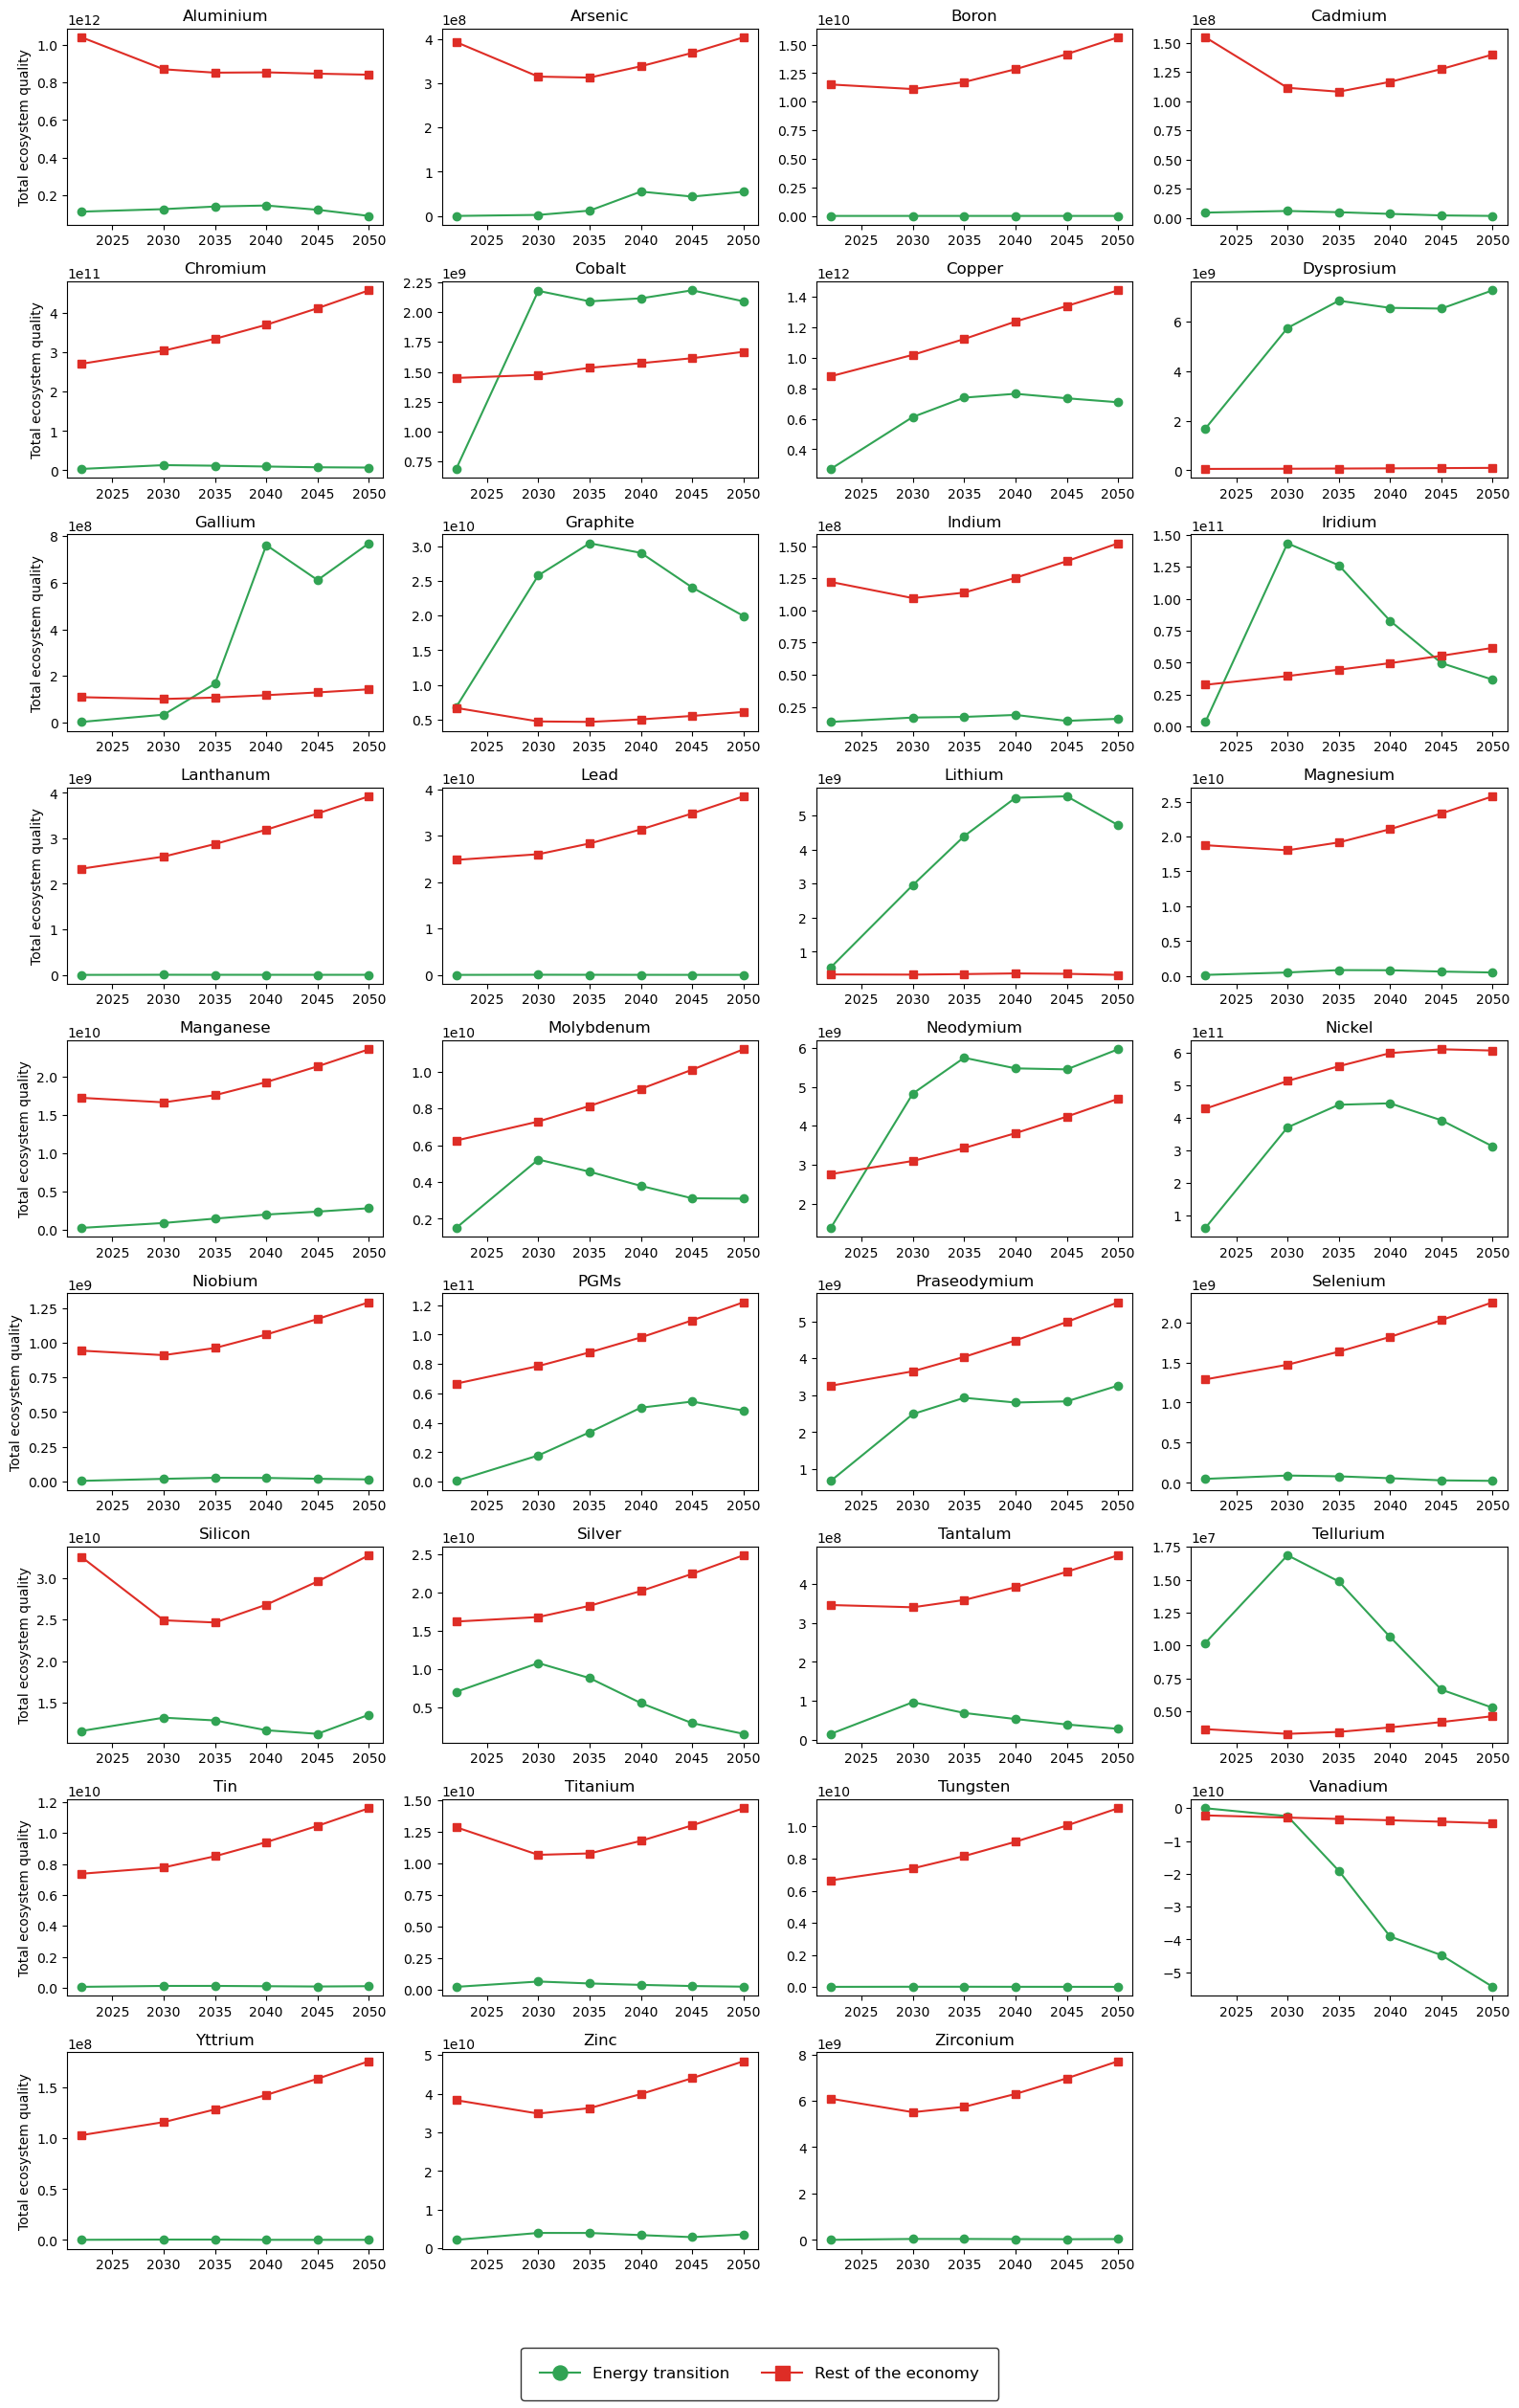

In [69]:
# Re-plot with NZE values aggregated by metal
plot_all_metals_subplots_damage(df_nze_damage, df_ssp2_damage,
                                           impact_type="Total ecosystem quality",
                                           save_path='results/plots/et_vs_roe/combined_subplots_impacts_eq',
                                           ncols=4)

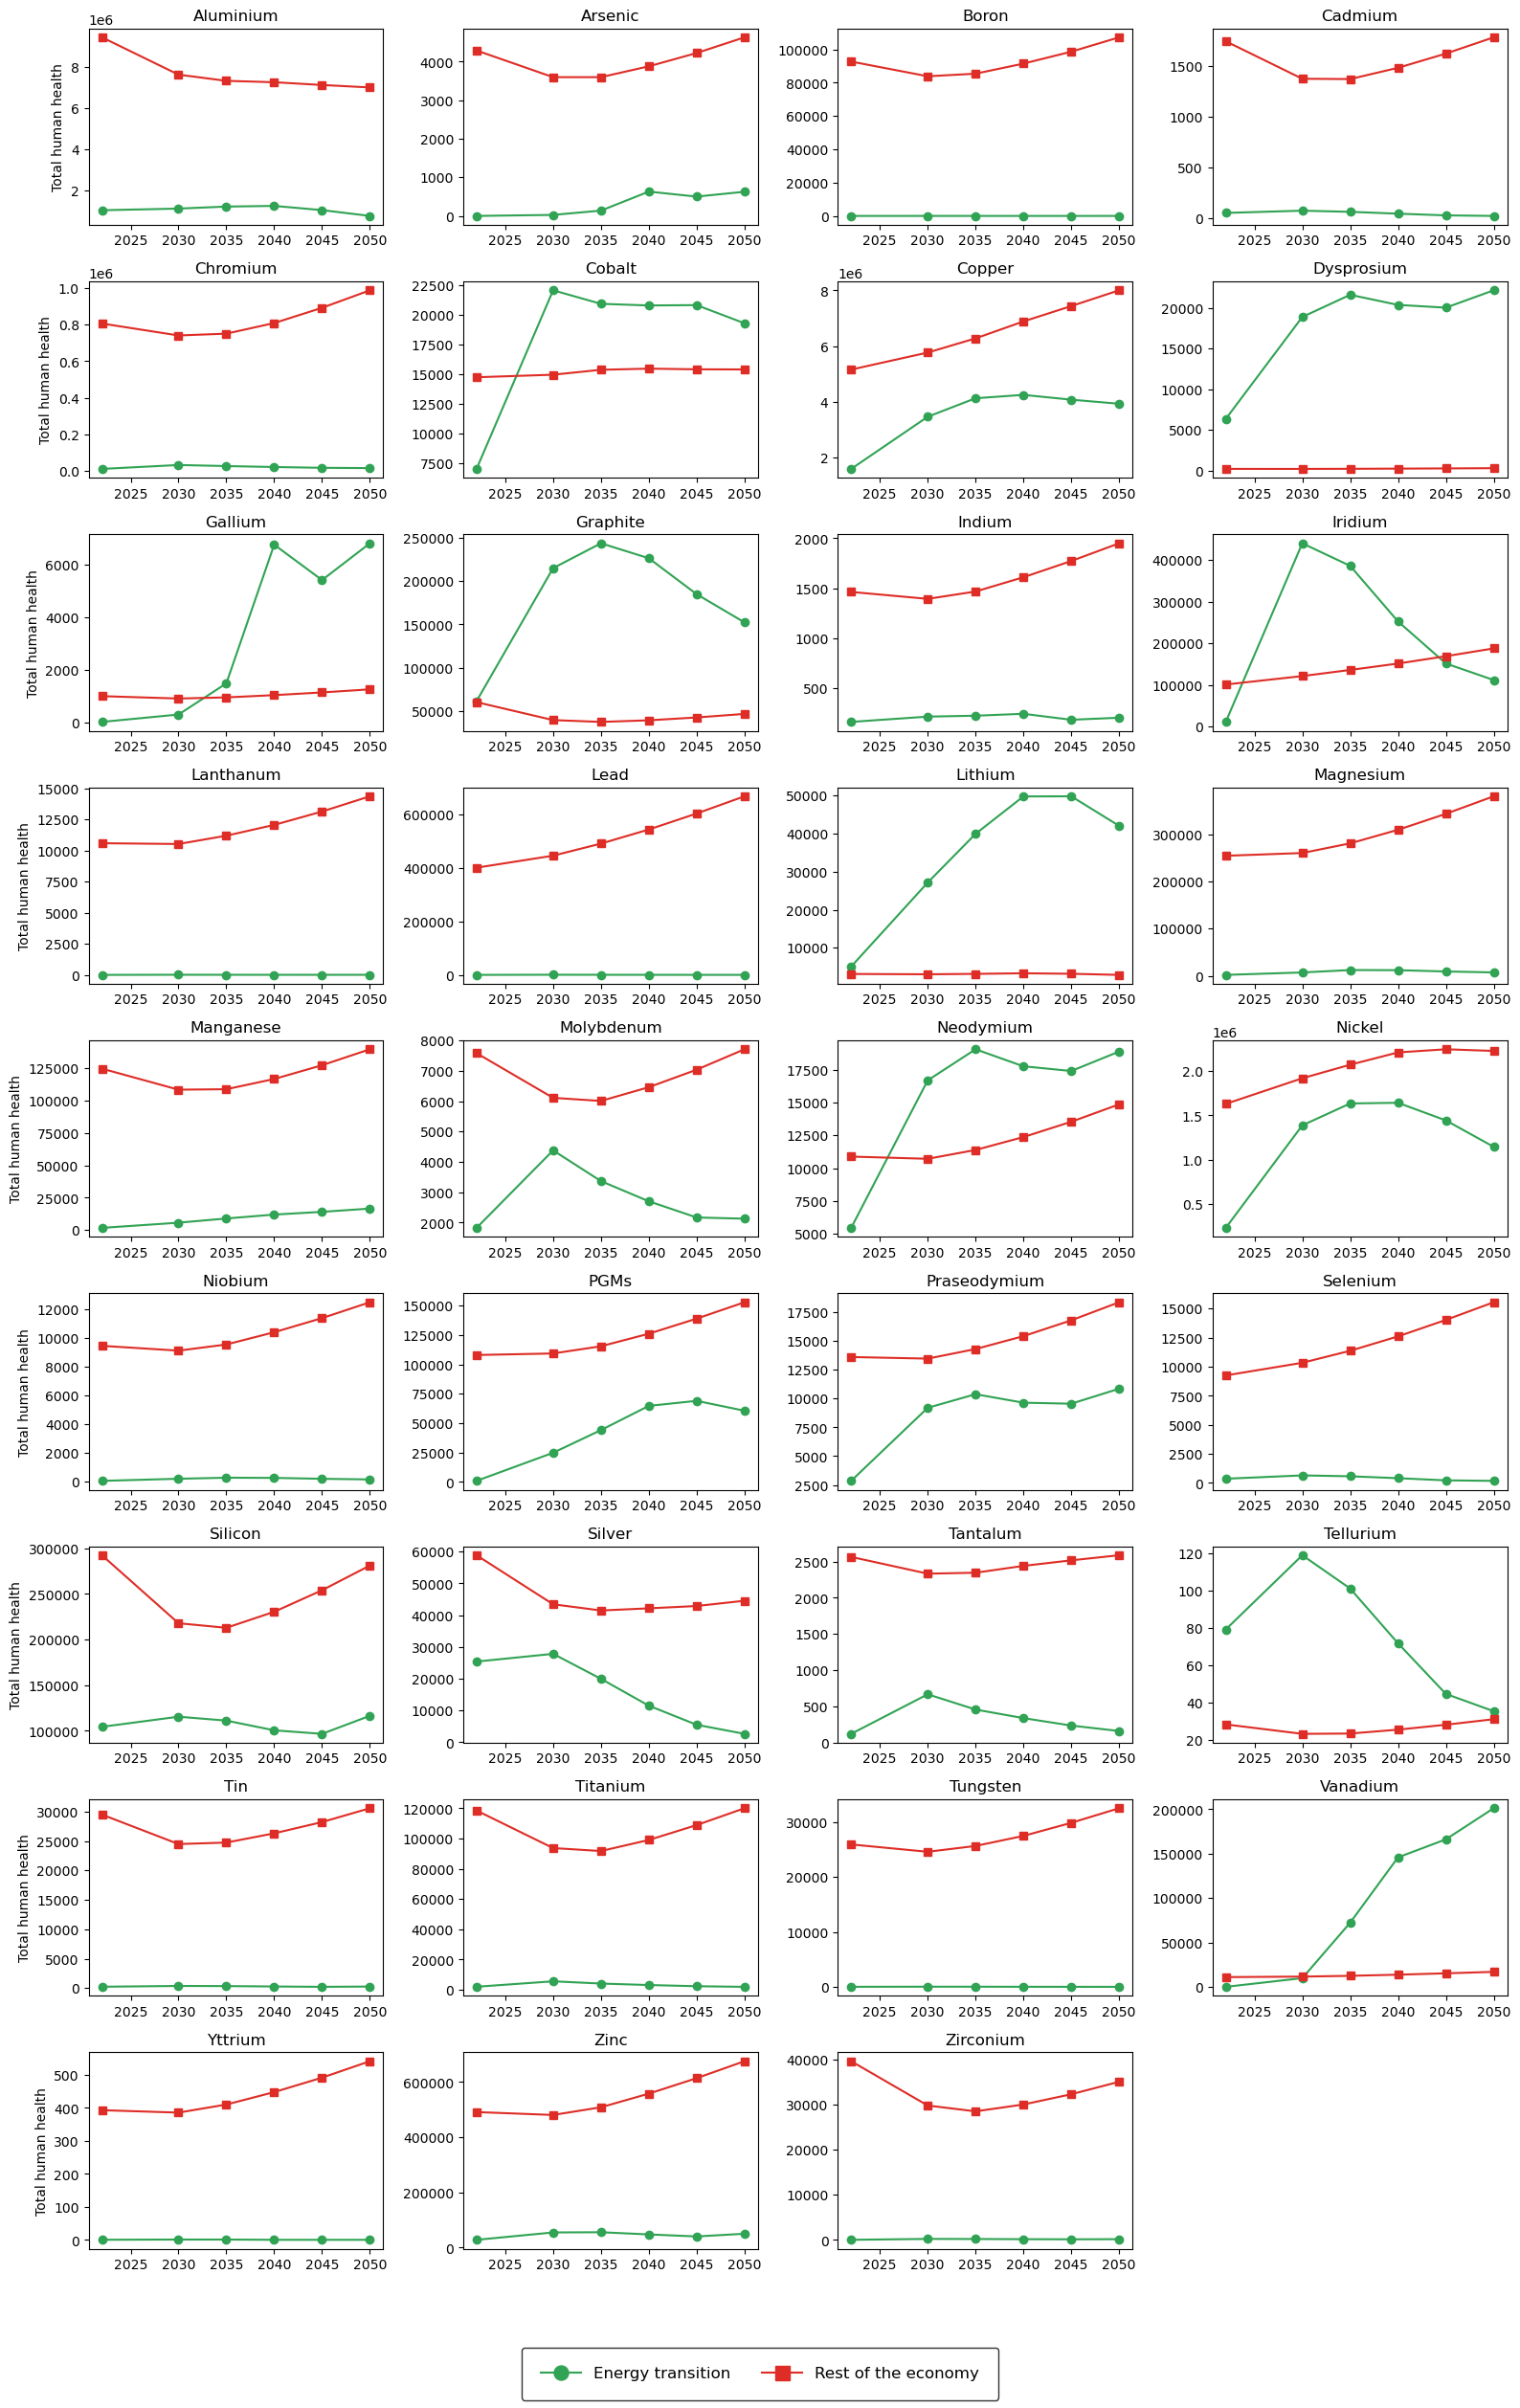

In [70]:
# Re-plot with NZE values aggregated by metal
plot_all_metals_subplots_damage(df_nze_damage, df_ssp2_damage,
                                           impact_type="Total human health",
                                    save_path='results/plots/et_vs_roe/combined_subplots_impacts_hh',
                                           ncols=4)

## Stacked area plot

In [18]:
from plotting_functions import plot_stacked_overlay
from constants import custom_metal_roe_colors

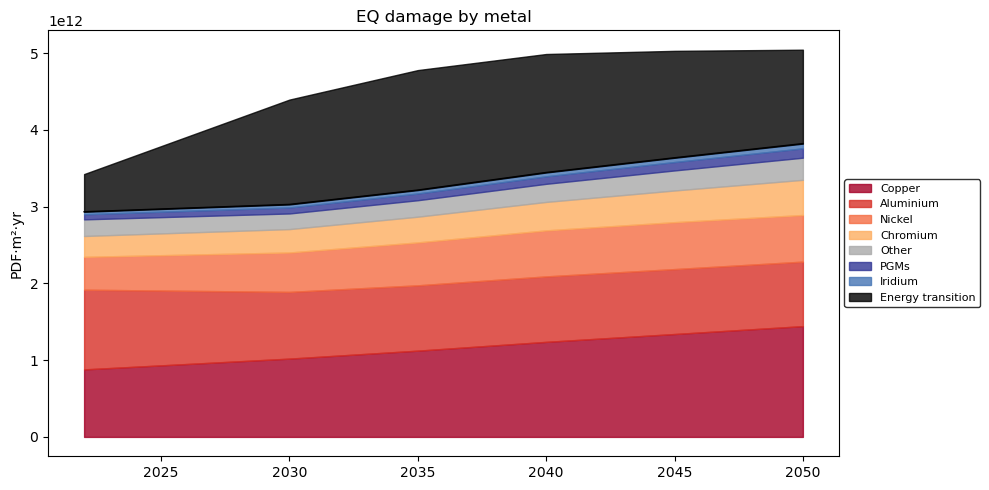

In [19]:
plot_stacked_overlay(df_nze_damage, df_ssp2_damage,
                                     group_by="Metal",
                                     value_col="Total ecosystem quality",
                                     title="EQ damage by metal",
                                    custom_colors=custom_metal_roe_colors,
                                    save_path='results/plots/et_vs_roe/plots_eq',
                                     y_label="PDF·m²·yr",
                                     threshold=0.01)

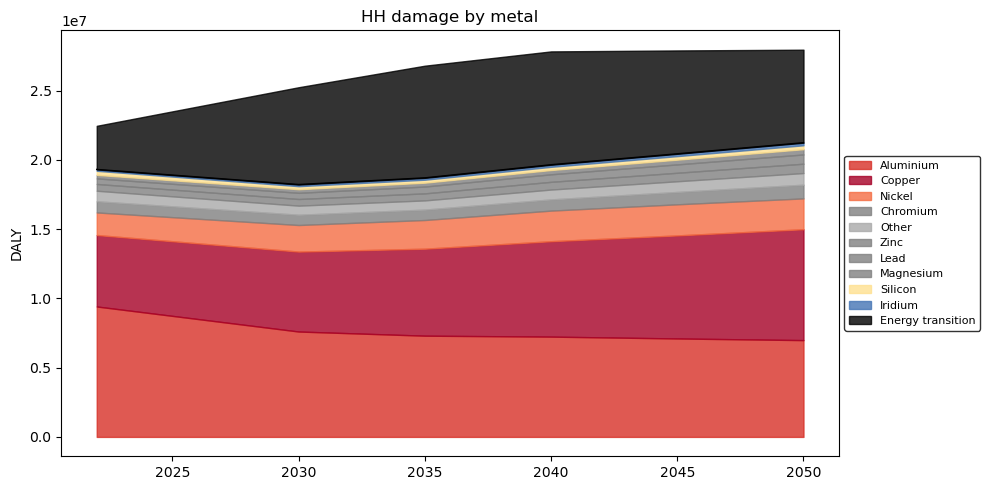

In [20]:
plot_stacked_overlay(df_nze_damage, df_ssp2_damage,
                                     group_by="Metal",
                                     value_col="Total human health",
                                     title="HH damage by metal",
                                    custom_colors=custom_metal_colors,
                                    save_path='results/plots/et_vs_roe/plots_hh',
                                     y_label="DALY",
                                     threshold=0.01)

In [21]:
from plotting_functions import plot_stacked_overlay_subplot

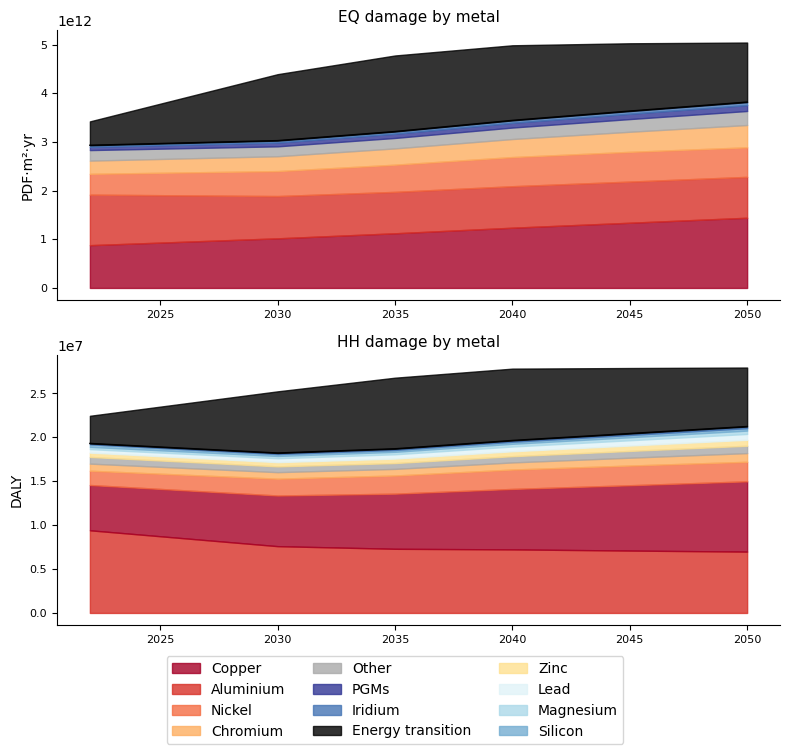

In [22]:
plot_stacked_overlay_subplot(
    df_nze=df_nze_damage,
    df_ssp2=df_ssp2_damage,
    group_by="Metal",
    value_cols=["Total ecosystem quality", "Total human health"],
    titles=["EQ damage by metal", "HH damage by metal"],
    y_labels=["PDF·m²·yr", "DALY"],
    custom_colors=custom_metal_roe_colors,
    save_path="results/plots/et_vs_roe/combined_overlay"
)
